In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as scs
import statsmodels.api as sm
import math 

mpl.rcParams['font.family'] = 'serif'

# §2 What is Market-Based Valuation?

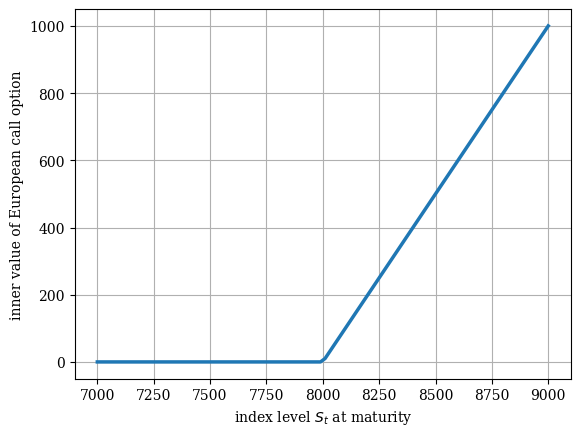

In [5]:
# 
# European Call Option Inner Value Plot

# Option Strike
K = 8000

#Graphical Output
S = np.linspace(7000, 9000, 100) # index level value
h = np.maximum(S - K, 0) # inner values of call option

plt.figure()
plt.plot(S, h, lw=2.5) # plot inner values at maturity
plt.xlabel('index level $S_t$ at maturity')
plt.ylabel('inner value of European call option')
plt.grid(True)

### Figure 2.2 
Black-Sholse-Merton value of a European call option on a stock index with K = 8000, T = 1.0, r = 0.025 and $\sigma$ = 0.2 dependent on the initial index level $S_0$ ; for comparison, the undiscounted inner value is also shown

In [26]:
from scipy.stats import norm

def BSM_call_value(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def BSM_put_value(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

Text(0, 0.5, 'present value $C(t=0)$')

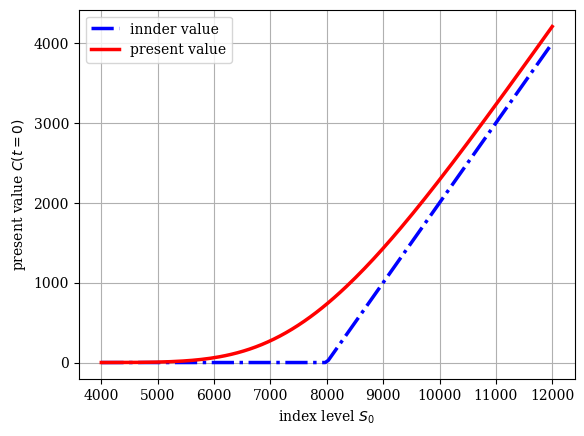

In [27]:
# Import Variation Function
import sys
sys.path.append('05_com')

# Model and Optionm Parameters
K = 8000 
T = 1.0
r = 0.025
vol = 0.2

# Sample Data Generation
S = np.linspace(4000, 12000, 150) # vector of index level values
h = np.maximum(S - K, 0) # innder value of option
C = [BSM_call_value(S0, K, T, r, vol) for S0 in S]
    # calculate call option values

# Graphical Output
plt.figure()
plt.plot(S, h, 'b-.', lw=2.5, label = 'innder value') # plot inner value at maturity
plt.plot(S, C, 'r', lw=2.5, label='present value') # plot option present value
plt.grid(True)
plt.legend(loc=0)
plt.xlabel('index level $S_0$')
plt.ylabel('present value $C(t=0)$')

# §3 Market Stylized Facts

- historical volatility

This refers to the standard deviation of log returns of financial time series; suppose we observe N(past) log returns $r_n, n \in \{1, \ldots, N\},$ with mean return
$$ \hat{\mu} = \frac{1}{N} \sum_{n=1}^{N} r_n$$
(Assume a time series with quotes $S_n, n\in \{0, \ldots, N\}.$ The log return for $n>0$ is defined by $r_n = \log S_n - \log S_{n - 1} = \log(S_n / S_{n-1})$)

the historical volatility $\hat{\sigma}$ is then given by
$$\hat{\sigma} = \sqrt{\frac{1}{N - 1} \sum_{n=1}^{N} (r_n - \hat{\mu})^2}$$
- instantaneous volatility

This referes to the volatility factor of a diffusion process; for example, in the Black-Scholes-Merton model the instaneous volatility $\sigma$ is found in the respective (risk-neutral) stochastic differential equation(SDE)
  $$dS_t = rS_t dt + \sigma S_t dZ_t$$
- implied volatility

this is the volatility that, if put into the Black-Scholes-Merton option pricing formula, gives the market-observed price of an option; suppose we observe today a price of $C_0^*$ for a European call option; the implied volatility $\sigma^{\text{imp}}$ is the quantity that solves ceteris paribus the implicit equation
$$C_0^* = C^{\text{BSM}}(S_0, K, T, r, \sigma^{\text{imp}})$$
These volatilities all have squared counterparts which are then named variance. For example, is some financial models where volatility is stochastic - in countrast to the BSM assumption - the variance is modeled instead of the volatility.

Two other (sample) moments of distribution are of importance:
 
- Skewness

this is a measure of the location of sample values relative to the mean("more to the left or more to the right"); again suppose we observe $N$(past) log returns $r_n, n \in \{1, \ldots, N\},$ with mean return $\hat{\mu}$; the (sample) skewness $\hat{s}$ is
$$\hat{s} = \frac{\frac{1}{N}\sum_{n=1}^{N}(r_n - \hat{\mu})^3}{\left(\frac{1}{N}\sum_{n=1}^{N}(r_n - \hat{\mu})^2\right)^{3/2}}$$

- Kurtosis

this is a measure for the peakedness of a distribution and/or the size of the tails of the distribution("fat tails" are implied by a high kurtosis); again suppose we observe $N$(past) log returns $r_n, n \in \{1, \ldots, N\},$ with mean return $\hat{\mu}$; the (sample) kurtosis $\hat{k}$ is

$$\hat{k} = \frac{\frac{1}{N}\sum_{n=1}^{N}(r_n - \hat{\mu})^4}{\left(\frac{1}{N}\sum_{n=1}^{N} (r_n - \hat{\mu})^2\right)^2} - 3$$
here 3 is subtracted such that the (standard) normal distribution has a kurtosis of 0.

Another important statistical notion is correlation. We mainly need to distinguish two types:

- Historical correlation

this referes to a measure for the co-movement of two final time series; suppose we observe from two series $a$ and $b$ a total of $N$(past) pairs of log returns $(r_n^a, r_n^b), n \in \{1, \ldots, N\},$ with mean returns $\hat{\mu}^a$ and $\hat{\mu}^b$; the historical (or sample) correlation $\hat{\rho}$ is then defined as
$$\hat{\rho} = \frac{\sum_{n=1}^{N}(r_n^a - \hat{\mu}^a)(r_n^b - \hat{\mu}^b)}{\sqrt{\sum_{n=1}^{N}(r_n^a - \hat{\mu}^a)^2 \sum_{n=1}^{N}(r_n^b - \hat{\mu}^b)^2}}$$

- instantaneous correlation

suppose we are given two standard Brownian motions $Z^a, Z^b$; the instantaneous correlation $\rho$ between both is then given by $\langle Z^a, Z^b\rangle_t = \rho t$ where denotes the $\langle\cdot\rangle_t$ denotes the quadratic variation process(cf. Protter(2005), pp.66-77); one can also write $dZ^adZ^b = \rho dt$ where the meaning of "instantaneous" becomes more evident

In [2]:
# GBM Analysis
#
# Analyzing Returns from Geometric Brownian Motion
# 03_stf/GBM_returns.py
#

def dN(x, mu, sigma):
    ''' Probability density function of a normal random variable x.
    
    Parameters
    ==============
    mu : float
        expected value
    sigma : float
        standard deviation

    Returns
    ==============
    pdf : float
        value of probability density function
    '''
    z = (x - mu) / sigma
    pdf = np.exp(-0.5 * z ** 2) / math.sqrt(2 * math.pi * sigma ** 2)
    return pdf
#
# Simulate a Number of Years of Daily Stock Quotes
#

def simulate_gbm():
    # model parameters
    S0 = 100.0 # initial index level
    T = 10.0 # time horizon
    r = 0.05 # risk-less short rate
    vol = 0.2 # instantaneous volatility

    # simulation parameters
    np.random.seed(250000)
    gbm_data = pd.Datetimendex(start = '30-09-2004',
                               end='31-07-2025',
                               freq = 'B')

    M = len(gbm_dates) # time steps
    I = 1 # index level paths
    dt = 1/252 # fixed for simplicity
    df = math.exp(-r * dt) # discount factor

      # stock price paths
    rand = np.random.standard_normal((M, I)) # random numbers
    S = np.zeros_like(rand) # stock matrix
    S[0] = S0 # initial values
    for t in range(1, M): # stock price paths
        S[t] = S([t - 1]) * np.exp((r - vol ** 2/2) * dt
                                   + vol * rand[t] * math.sqrt(dt))
    gbm = pd.DataFrame(S[:, 0], index=gbm_dates, columns=['index'])
    gbm['returns'] = np.log(gbm['index'] / gbm['index'].shift(1))

   # Realized Vpolatility (eg. as defined for variance swaps)
    gbm['rea_var'] = 252 * np.cumcum(gbm['returns'] ** 2) / np.arrange(len(gbm))
    gbm['rea_vol'] = np.sqrt(gbm['rea_var'])
    gbm = gbm.dropna()
    return gbm

# Return Sample Statistics and Normality Tests
def print_statistics(data):
    print "RETURN SAMPLE STATISTICS"
    print "-----------------------------------------"
    print "Mean of Daily  Log Returns %9.6f" % np.mean(data['returns'])
    print "Std  of Daily  Log Returns %9.6f" % np.std(data['returns'])
    print "Mean of Annua. Log Returns %9.6f" % (np.mean(data['returns']) * 252)
    print "Std of Annua.  Log Reutnrs %9.6f" % \
                (np.std(data['returns']) * math.sqrt(252))
    print "-----------------------------------------"
    print "Skew of Sample Log Returns %9.6f" % scs.skew(data['returns'])
    print "Skew Normal Test p-value   %9.6f" % scs.skewtest(data['returns'])[1]
    print "-----------------------------------------"
    print "Kurt of Sample Log Returns %9.6f" % scs.kurtosis(data['returns'])
    print "Kurt Normal Test p-value   %9.6f" \
                scs.kurtosistest(data['returns'])[1]
    print "-----------------------------------------"
    print "Realized Volatility        %9.6f" % data['rea_vol'].iloc[-1]
    print "Realized Variance          %9.6f" % data['rea_var'].iloc[-1]

#
# Graphical Output
#

# daily quotes and log returns
def quotes_returns(data):
    '''Plots quotes and returns '''
    plt.figure(figsize=(9, 6))
    plt.subplot(211)
    data['index'].plot()
    plt.ylabel('daily quotes')

                               
    

SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)? (1349089419.py, line 65)

In [ ]:
p